In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
DATA_PATH = "../data/raw/UCI_HAR"
print(os.listdir(DATA_PATH))

['activity_labels.txt', 'features.txt', 'features_info.txt', 'RawData', 'README.txt', 'Test', 'Train']


In [3]:
print("TRAIN:")
print(os.listdir(DATA_PATH + "/Train"))

print("\nTEST:")
print(os.listdir(DATA_PATH + "/Test"))

print("\nRAWDATA:")
print(os.listdir(DATA_PATH + "/RawData"))

TRAIN:
['subject_id_train.txt', 'X_train.txt', 'y_train.txt']

TEST:
['subject_id_test.txt', 'X_test.txt', 'y_test.txt']

RAWDATA:
['acc_exp01_user01.txt', 'acc_exp02_user01.txt', 'acc_exp03_user02.txt', 'acc_exp04_user02.txt', 'acc_exp05_user03.txt', 'acc_exp06_user03.txt', 'acc_exp07_user04.txt', 'acc_exp08_user04.txt', 'acc_exp09_user05.txt', 'acc_exp10_user05.txt', 'acc_exp11_user06.txt', 'acc_exp12_user06.txt', 'acc_exp13_user07.txt', 'acc_exp14_user07.txt', 'acc_exp15_user08.txt', 'acc_exp16_user08.txt', 'acc_exp17_user09.txt', 'acc_exp18_user09.txt', 'acc_exp19_user10.txt', 'acc_exp20_user10.txt', 'acc_exp21_user10.txt', 'acc_exp22_user11.txt', 'acc_exp23_user11.txt', 'acc_exp24_user12.txt', 'acc_exp25_user12.txt', 'acc_exp26_user13.txt', 'acc_exp27_user13.txt', 'acc_exp28_user14.txt', 'acc_exp29_user14.txt', 'acc_exp30_user15.txt', 'acc_exp31_user15.txt', 'acc_exp32_user16.txt', 'acc_exp33_user16.txt', 'acc_exp34_user17.txt', 'acc_exp35_user17.txt', 'acc_exp36_user18.txt', 'acc

In [4]:
train_path = DATA_PATH + "/Train"
test_path = DATA_PATH + "/Test"

X_train = np.loadtxt(train_path + "/X_train.txt")
y_train = np.loadtxt(train_path + "/y_train.txt").astype(int)

X_test = np.loadtxt(test_path + "/X_test.txt")
y_test = np.loadtxt(test_path + "/y_test.txt").astype(int)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (7767, 561)
y_train shape: (7767,)
X_test shape: (3162, 561)
y_test shape: (3162,)


In [5]:
# Load activity labels
activity_labels = pd.read_csv(
    DATA_PATH + "/activity_labels.txt",
    sep=r"\s+",
    header=None,
    names=["id", "activity"]
)

# Load feature names
features = pd.read_csv(
    DATA_PATH + "/features.txt",
    sep=r"\s+",
    header=None,
    names=["id", "feature"]
)

print("ACTIVITIES:")
print(activity_labels)

print("\nNUMBER OF FEATURES:", len(features))

print("\nFIRST 20 FEATURES:")
print(features.head(20))

ACTIVITIES:
    id            activity
0    1             WALKING
1    2    WALKING_UPSTAIRS
2    3  WALKING_DOWNSTAIRS
3    4             SITTING
4    5            STANDING
5    6              LAYING
6    7        STAND_TO_SIT
7    8        SIT_TO_STAND
8    9          SIT_TO_LIE
9   10          LIE_TO_SIT
10  11        STAND_TO_LIE
11  12        LIE_TO_STAND

NUMBER OF FEATURES: 561

FIRST 20 FEATURES:
                   id  feature
0     tBodyAcc-Mean-1      NaN
1     tBodyAcc-Mean-2      NaN
2     tBodyAcc-Mean-3      NaN
3      tBodyAcc-STD-1      NaN
4      tBodyAcc-STD-2      NaN
5      tBodyAcc-STD-3      NaN
6      tBodyAcc-Mad-1      NaN
7      tBodyAcc-Mad-2      NaN
8      tBodyAcc-Mad-3      NaN
9      tBodyAcc-Max-1      NaN
10     tBodyAcc-Max-2      NaN
11     tBodyAcc-Max-3      NaN
12     tBodyAcc-Min-1      NaN
13     tBodyAcc-Min-2      NaN
14     tBodyAcc-Min-3      NaN
15     tBodyAcc-SMA-1      NaN
16  tBodyAcc-Energy-1      NaN
17  tBodyAcc-Energy-2      NaN
18 

In [7]:
features = pd.read_csv(
    DATA_PATH + "/features.txt",
    sep=r"\s+",
    header=None,
    names=["feature"],
    engine="python"
)

print("Number of features:", len(features))

print("\nFirst 20 features:")
print(features.head(20).to_string(index=False))

Number of features: 561

First 20 features:
          feature
  tBodyAcc-Mean-1
  tBodyAcc-Mean-2
  tBodyAcc-Mean-3
   tBodyAcc-STD-1
   tBodyAcc-STD-2
   tBodyAcc-STD-3
   tBodyAcc-Mad-1
   tBodyAcc-Mad-2
   tBodyAcc-Mad-3
   tBodyAcc-Max-1
   tBodyAcc-Max-2
   tBodyAcc-Max-3
   tBodyAcc-Min-1
   tBodyAcc-Min-2
   tBodyAcc-Min-3
   tBodyAcc-SMA-1
tBodyAcc-Energy-1
tBodyAcc-Energy-2
tBodyAcc-Energy-3
   tBodyAcc-IQR-1


In [8]:
# Map activity IDs to activity names
activity_map = dict(
    zip(activity_labels["id"], activity_labels["activity"])
)

# Convert numeric labels into activity names
y_train_names = pd.Series(y_train).map(activity_map)
y_test_names = pd.Series(y_test).map(activity_map)

print("Training data distribution:")
print(y_train_names.value_counts())

print("\nTesting data distribution:")
print(y_test_names.value_counts())

Training data distribution:
STANDING              1423
LAYING                1413
SITTING               1293
WALKING               1226
WALKING_UPSTAIRS      1073
WALKING_DOWNSTAIRS     987
STAND_TO_LIE            90
SIT_TO_LIE              75
LIE_TO_SIT              60
LIE_TO_STAND            57
STAND_TO_SIT            47
SIT_TO_STAND            23
Name: count, dtype: int64

Testing data distribution:
STANDING              556
LAYING                545
SITTING               508
WALKING               496
WALKING_UPSTAIRS      471
WALKING_DOWNSTAIRS    420
STAND_TO_LIE           49
SIT_TO_LIE             32
LIE_TO_STAND           27
LIE_TO_SIT             25
STAND_TO_SIT           23
SIT_TO_STAND           10
Name: count, dtype: int64


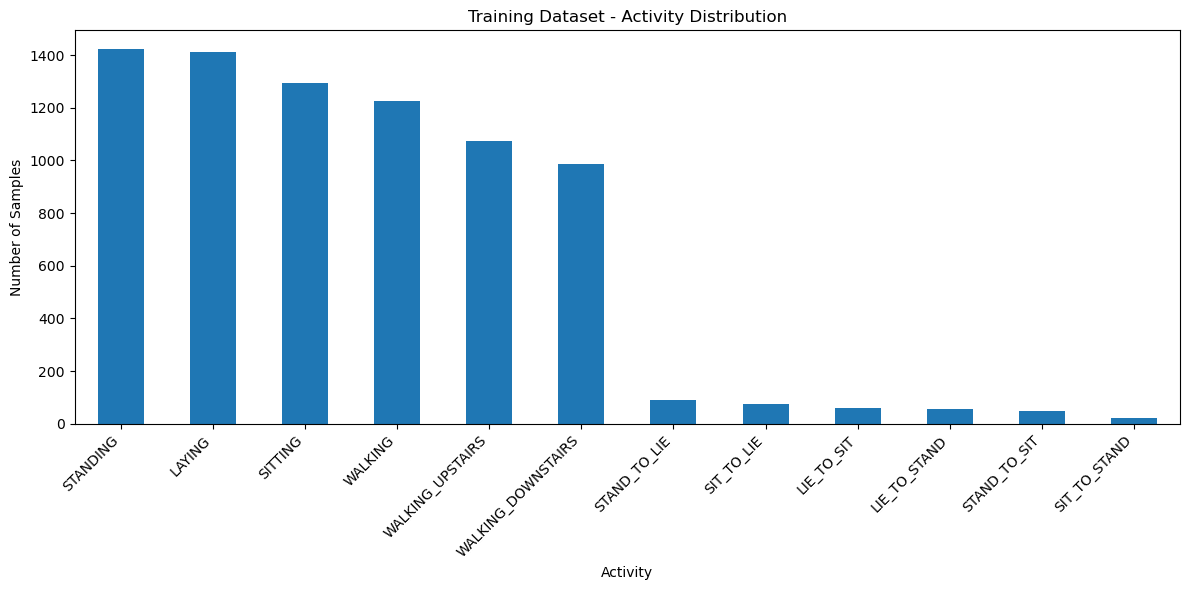

In [9]:
# Plot training activity distribution

plt.figure(figsize=(12, 6))

y_train_names.value_counts().plot(kind="bar")

plt.title("Training Dataset - Activity Distribution")
plt.xlabel("Activity")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [10]:
# Load one raw accelerometer recording

raw_acc_path = DATA_PATH + "/RawData/acc_exp01_user01.txt"

acc_data = np.loadtxt(raw_acc_path)

print("Shape of raw accelerometer data:", acc_data.shape)

print("\nFirst 10 rows:")
print(acc_data[:10])

Shape of raw accelerometer data: (20598, 3)

First 10 rows:
[[ 0.91805559 -0.1125      0.50972225]
 [ 0.91111113 -0.09305556  0.53750004]
 [ 0.8819445  -0.08611111  0.51388893]
 [ 0.8819445  -0.08611111  0.51388893]
 [ 0.87916671 -0.1         0.50555558]
 [ 0.88888896 -0.10555556  0.51250004]
 [ 0.86250001 -0.10138889  0.50972225]
 [ 0.86111112 -0.10416667  0.5013889 ]
 [ 0.85416666 -0.10833334  0.5277778 ]
 [ 0.85138888 -0.10138889  0.5527778 ]]


In [12]:
# Load the corresponding raw gyroscope recording
raw_gyro_path = DATA_PATH + "/RawData/gyro_exp01_user01.txt"

gyro_data = np.loadtxt(raw_gyro_path)

print("Shape of raw gyroscope data:", gyro_data.shape)

print("\nFirst 10 rows:")
print(gyro_data[:10])

Shape of raw gyroscope data: (20598, 3)

First 10 rows:
[[-0.05497787 -0.06963864 -0.03084869]
 [-0.01252274  0.01924226 -0.03848451]
 [-0.02351831  0.27641651  0.00641409]
 [-0.09346239  0.36774087  0.00122173]
 [-0.12431107  0.47678033 -0.02290745]
 [-0.10048734  0.51984632 -0.06750061]
 [-0.14935656  0.48105639 -0.09254608]
 [-0.21105394  0.38912117 -0.07483099]
 [-0.22235495  0.26786441 -0.05192355]
 [-0.17379116  0.20708331 -0.03207042]]


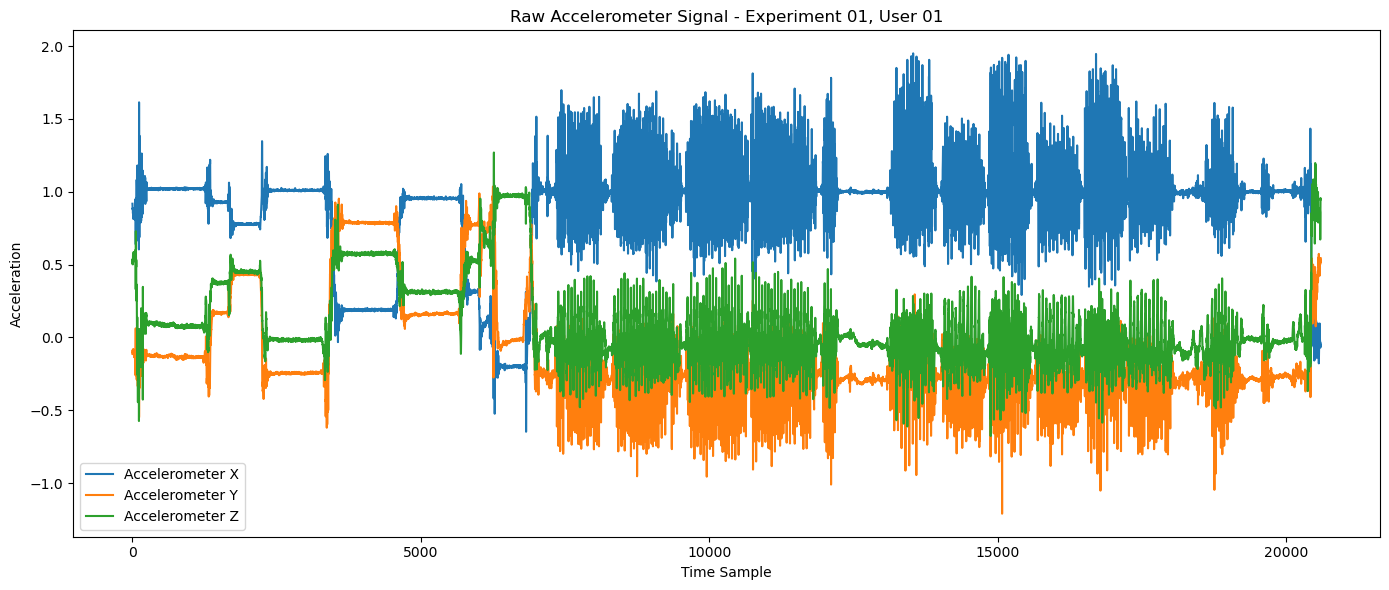

In [13]:
# Plot raw accelerometer signals

plt.figure(figsize=(14, 6))

plt.plot(acc_data[:, 0], label="Accelerometer X")
plt.plot(acc_data[:, 1], label="Accelerometer Y")
plt.plot(acc_data[:, 2], label="Accelerometer Z")

plt.title("Raw Accelerometer Signal - Experiment 01, User 01")
plt.xlabel("Time Sample")
plt.ylabel("Acceleration")
plt.legend()

plt.tight_layout()
plt.show()

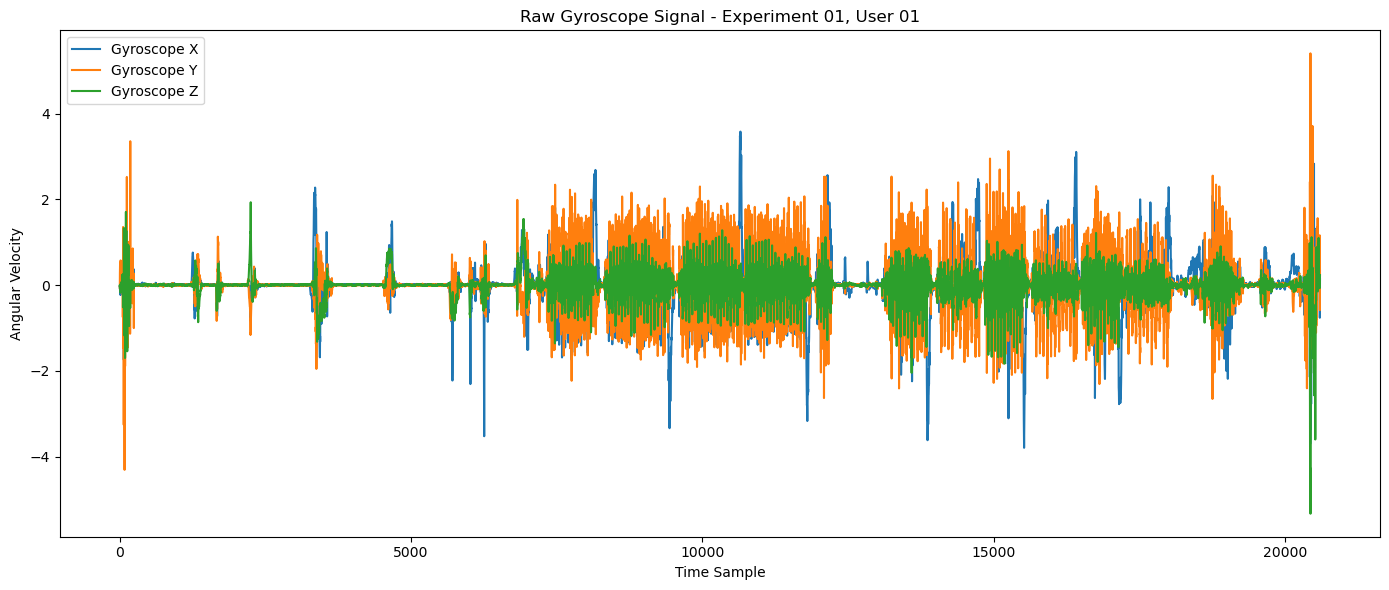

In [14]:
# Plot raw gyroscope signals

plt.figure(figsize=(14, 6))

plt.plot(gyro_data[:, 0], label="Gyroscope X")
plt.plot(gyro_data[:, 1], label="Gyroscope Y")
plt.plot(gyro_data[:, 2], label="Gyroscope Z")

plt.title("Raw Gyroscope Signal - Experiment 01, User 01")
plt.xlabel("Time Sample")
plt.ylabel("Angular Velocity")
plt.legend()

plt.tight_layout()
plt.show()

In [15]:
# Load labels for the raw sensor recordings

labels_path = DATA_PATH + "/RawData/labels.txt"

raw_labels = np.loadtxt(labels_path)

print("Labels shape:", raw_labels.shape)

print("\nFirst 10 labels:")
print(raw_labels[:10])

Labels shape: (1214, 5)

First 10 labels:
[[1.000e+00 1.000e+00 5.000e+00 2.500e+02 1.232e+03]
 [1.000e+00 1.000e+00 7.000e+00 1.233e+03 1.392e+03]
 [1.000e+00 1.000e+00 4.000e+00 1.393e+03 2.194e+03]
 [1.000e+00 1.000e+00 8.000e+00 2.195e+03 2.359e+03]
 [1.000e+00 1.000e+00 5.000e+00 2.360e+03 3.374e+03]
 [1.000e+00 1.000e+00 1.100e+01 3.375e+03 3.662e+03]
 [1.000e+00 1.000e+00 6.000e+00 3.663e+03 4.538e+03]
 [1.000e+00 1.000e+00 1.000e+01 4.539e+03 4.735e+03]
 [1.000e+00 1.000e+00 4.000e+00 4.736e+03 5.667e+03]
 [1.000e+00 1.000e+00 9.000e+00 5.668e+03 5.859e+03]]


In [16]:
# Convert raw activity IDs to activity names

raw_labels_df = pd.DataFrame(
    raw_labels,
    columns=[
        "experiment",
        "user",
        "activity_id",
        "start_sample",
        "end_sample"
    ]
)

raw_labels_df["activity"] = (
    raw_labels_df["activity_id"]
    .astype(int)
    .map(activity_map)
)

print(raw_labels_df.head(10).to_string(index=False))

 experiment  user  activity_id  start_sample  end_sample     activity
        1.0   1.0          5.0         250.0      1232.0     STANDING
        1.0   1.0          7.0        1233.0      1392.0 STAND_TO_SIT
        1.0   1.0          4.0        1393.0      2194.0      SITTING
        1.0   1.0          8.0        2195.0      2359.0 SIT_TO_STAND
        1.0   1.0          5.0        2360.0      3374.0     STANDING
        1.0   1.0         11.0        3375.0      3662.0 STAND_TO_LIE
        1.0   1.0          6.0        3663.0      4538.0       LAYING
        1.0   1.0         10.0        4539.0      4735.0   LIE_TO_SIT
        1.0   1.0          4.0        4736.0      5667.0      SITTING
        1.0   1.0          9.0        5668.0      5859.0   SIT_TO_LIE


In [17]:
# Calculate the length of each labeled segment

raw_labels_df["num_samples"] = (
    raw_labels_df["end_sample"] - raw_labels_df["start_sample"] + 1
)

print(
    raw_labels_df[
        ["activity", "num_samples"]
    ].head(20).to_string(index=False)
)

          activity  num_samples
          STANDING        983.0
      STAND_TO_SIT        160.0
           SITTING        802.0
      SIT_TO_STAND        165.0
          STANDING       1015.0
      STAND_TO_LIE        288.0
            LAYING        876.0
        LIE_TO_SIT        197.0
           SITTING        932.0
        SIT_TO_LIE        192.0
            LAYING        927.0
      LIE_TO_STAND        191.0
           WALKING        583.0
           WALKING        895.0
           WALKING        911.0
           WALKING        965.0
WALKING_DOWNSTAIRS        656.0
  WALKING_UPSTAIRS        631.0
WALKING_DOWNSTAIRS        624.0
  WALKING_UPSTAIRS        666.0


In [18]:
# Segment length statistics for each activity

segment_stats = (
    raw_labels_df
    .groupby("activity")["num_samples"]
    .agg(["count", "min", "max", "mean"])
    .sort_values("mean", ascending=False)
)

print(segment_stats)

                    count    min     max         mean
activity                                             
STANDING              120  760.0  2032.0  1150.875000
LAYING                120  778.0  1695.0  1140.541667
SITTING               120  623.0  1622.0  1055.641667
WALKING               127  141.0  1411.0   961.346457
WALKING_UPSTAIRS      183  222.0   895.0   637.743169
WALKING_DOWNSTAIRS    186  216.0   880.0   580.435484
STAND_TO_LIE           58  139.0   494.0   248.586207
SIT_TO_LIE             60  136.0   326.0   207.133333
LIE_TO_STAND           58  118.0   323.0   187.362069
LIE_TO_SIT             60  114.0   280.0   185.833333
STAND_TO_SIT           60   90.0   307.0   171.933333
SIT_TO_STAND           62   74.0   183.0   129.500000


In [19]:
# Sampling rate of the raw IMU signals

sampling_rate = 50  # Hz

print("Sampling rate:", sampling_rate, "Hz")
print("Samples per second:", sampling_rate)

# Check common window sizes
for seconds in [1, 2, 2.56, 3]:
    samples = int(seconds * sampling_rate)
    print(f"{seconds} seconds = {samples} samples")

Sampling rate: 50 Hz
Samples per second: 50
1 seconds = 50 samples
2 seconds = 100 samples
2.56 seconds = 128 samples
3 seconds = 150 samples
